Predicting the House Prices (In-Depth Regression Analysis)

Importing all the required Libraries

In [52]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, r2_score
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, mean_squared_error
from imblearn.over_sampling import SMOTE

Reading the Dataset and doing the EDA on the Dataset

In [53]:
df = pd.read_csv('House_Prices.csv')
df.head(10)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
6,2014-05-02 00:00:00,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,1976,0,2616 174th Ave NE,Redmond,WA 98052,USA
7,2014-05-02 00:00:00,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,1989,0,23762 SE 253rd Pl,Maple Valley,WA 98038,USA
8,2014-05-02 00:00:00,452500.0,3.0,2.50,2430,88426,1.0,0,0,4,1570,860,1985,0,46611-46625 SE 129th St,North Bend,WA 98045,USA
9,2014-05-02 00:00:00,640000.0,4.0,2.00,1520,6200,1.5,0,0,3,1520,0,1945,2010,6811 55th Ave NE,Seattle,WA 98115,USA


In [54]:
df.shape

(4600, 18)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [56]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


### 📌 Feature Engineering: Handling `statezip` Column

During initial data exploration, the `statezip` column was analyzed to understand its structure and usefulness.

- It was observed that all values in `statezip` follow the format: **"WA XXXXX"**
- The prefix **"WA" (state)** is constant across all rows and does not provide any meaningful variation or predictive value.
- The **ZIP code portion (e.g., 98119, 98115, etc.)** varies across observations and represents more granular location information.

#### ✅ Actions Taken:
- Extracted the ZIP code from `statezip` to retain useful geographical information.
- Dropped the original `statezip` column to remove redundancy.
- Stored the extracted ZIP codes as a categorical feature (`zip_code`) for further analysis and encoding.

#### 🎯 Reasoning:
- Constant features do not contribute to model learning and can be safely removed.
- ZIP codes capture neighborhood-level differences, which can significantly impact house prices.
- Transforming raw features into meaningful components improves model performance and interpretability.

#### 🚀 Outcome:
This step ensures that only relevant and informative location-based features are used in the model, reducing noise and improving predictive capability.

In [57]:
df['city'].value_counts()

Seattle                1573
Renton                  293
Bellevue                286
Redmond                 235
Issaquah                187
Kirkland                187
Kent                    185
Auburn                  176
Sammamish               175
Federal Way             148
Shoreline               123
Woodinville             115
Maple Valley             96
Mercer Island            86
Burien                   74
Snoqualmie               71
Kenmore                  66
Des Moines               58
North Bend               50
Covington                43
Duvall                   42
Lake Forest Park         36
Bothell                  33
Newcastle                33
SeaTac                   29
Tukwila                  29
Vashon                   29
Enumclaw                 28
Carnation                22
Normandy Park            18
Clyde Hill               11
Medina                   11
Fall City                11
Black Diamond             9
Ravensdale                7
Pacific             

In [58]:
df['statezip'].value_counts()

WA 98103    148
WA 98052    135
WA 98117    132
WA 98115    130
WA 98006    110
           ... 
WA 98047      6
WA 98288      3
WA 98050      2
WA 98354      2
WA 98068      1
Name: statezip, Length: 77, dtype: int64

In [59]:
df['statezip'].unique()

array(['WA 98133', 'WA 98119', 'WA 98042', 'WA 98008', 'WA 98052',
       'WA 98115', 'WA 98038', 'WA 98045', 'WA 98155', 'WA 98105',
       'WA 98074', 'WA 98106', 'WA 98007', 'WA 98092', 'WA 98198',
       'WA 98006', 'WA 98102', 'WA 98011', 'WA 98125', 'WA 98003',
       'WA 98136', 'WA 98033', 'WA 98029', 'WA 98117', 'WA 98034',
       'WA 98072', 'WA 98023', 'WA 98107', 'WA 98166', 'WA 98116',
       'WA 98024', 'WA 98055', 'WA 98077', 'WA 98027', 'WA 98059',
       'WA 98075', 'WA 98014', 'WA 98065', 'WA 98199', 'WA 98053',
       'WA 98058', 'WA 98122', 'WA 98103', 'WA 98112', 'WA 98005',
       'WA 98118', 'WA 98177', 'WA 98004', 'WA 98019', 'WA 98144',
       'WA 98168', 'WA 98001', 'WA 98056', 'WA 98146', 'WA 98028',
       'WA 98148', 'WA 98057', 'WA 98040', 'WA 98010', 'WA 98051',
       'WA 98031', 'WA 98109', 'WA 98030', 'WA 98126', 'WA 98032',
       'WA 98178', 'WA 98288', 'WA 98108', 'WA 98070', 'WA 98188',
       'WA 98002', 'WA 98039', 'WA 98022', 'WA 98068', 'WA 980

In [60]:
df['country'].value_counts()

USA    4600
Name: country, dtype: int64

In [61]:
df[(df['city'] == 'Seattle') & (df['statezip'] == 'WA 98119')].shape

(49, 18)

In [62]:
df[(df['city'] == 'Seattle') & (df['statezip'] == 'WA 98115')].shape


(130, 18)

Extracting the zip code from the statezip column

In [63]:
df['zip_code'] = df['statezip'].str.split().str[1]

Droppig the original columns statezip as it is redundant 

In [64]:
df.drop(columns= ['statezip'], inplace= True)

Dropping the street column as it os redundant

In [65]:
df.drop(columns= ['street'], inplace= True)

Dropping the country Column too as its the same across the entire dataset and for this we will just be seeing the house prices for USA

In [66]:
df.drop(columns= ['country'], inplace= True)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  city           4600 non-null   object 
 15  zip_code       4600 non-null   object 
dtypes: float64(4), int64(9), object(3)
memory usage: 575.1+ KB


In [68]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,zip_code
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,98133
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,98119
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,98042
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,98008
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,98052


Converting the type of the date Column

In [69]:
df['date'] = pd.to_datetime(df['date'])

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4600 non-null   datetime64[ns]
 1   price          4600 non-null   float64       
 2   bedrooms       4600 non-null   float64       
 3   bathrooms      4600 non-null   float64       
 4   sqft_living    4600 non-null   int64         
 5   sqft_lot       4600 non-null   int64         
 6   floors         4600 non-null   float64       
 7   waterfront     4600 non-null   int64         
 8   view           4600 non-null   int64         
 9   condition      4600 non-null   int64         
 10  sqft_above     4600 non-null   int64         
 11  sqft_basement  4600 non-null   int64         
 12  yr_built       4600 non-null   int64         
 13  yr_renovated   4600 non-null   int64         
 14  city           4600 non-null   object        
 15  zip_code       4600 n

Converting the city and the zip code as a category varibale 

In [71]:
df['city'] = df['city'].astype('category')
df['zip_code'] = df['zip_code'].astype('category')

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4600 non-null   datetime64[ns]
 1   price          4600 non-null   float64       
 2   bedrooms       4600 non-null   float64       
 3   bathrooms      4600 non-null   float64       
 4   sqft_living    4600 non-null   int64         
 5   sqft_lot       4600 non-null   int64         
 6   floors         4600 non-null   float64       
 7   waterfront     4600 non-null   int64         
 8   view           4600 non-null   int64         
 9   condition      4600 non-null   int64         
 10  sqft_above     4600 non-null   int64         
 11  sqft_basement  4600 non-null   int64         
 12  yr_built       4600 non-null   int64         
 13  yr_renovated   4600 non-null   int64         
 14  city           4600 non-null   category      
 15  zip_code       4600 n

In [73]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,zip_code
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,98133
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,98119
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,98042
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,98008
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,98052


Checking if there are any null values or not 

In [74]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
city             0
zip_code         0
dtype: int64

Chekcing for the % of null values of the columns which will help in making better decisions on how the columns should do (i.e to keep it or to drop it or to impute it)

In [75]:
(df.isnull().sum() / len(df)) * 100

date             0.0
price            0.0
bedrooms         0.0
bathrooms        0.0
sqft_living      0.0
sqft_lot         0.0
floors           0.0
waterfront       0.0
view             0.0
condition        0.0
sqft_above       0.0
sqft_basement    0.0
yr_built         0.0
yr_renovated     0.0
city             0.0
zip_code         0.0
dtype: float64

#### Now starts the Visualization 📊📈📉

In [76]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,zip_code
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,98133
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,98119
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,98042
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,98008
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,98052


##### First seperating the column into numerical and categorical columns 

In [77]:
# Numerical Columns
num_cols = df.select_dtypes(include= ['int64', 'float64']).columns

# Categorical Columns
cat_cols = df.select_dtypes(include= ['category', 'object']).columns

In [78]:
num_cols

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated'],
      dtype='object')

In [79]:
cat_cols

Index(['city', 'zip_code'], dtype='object')

##### Visualizing the Numerical Columns

###### (A) Distribution Plots

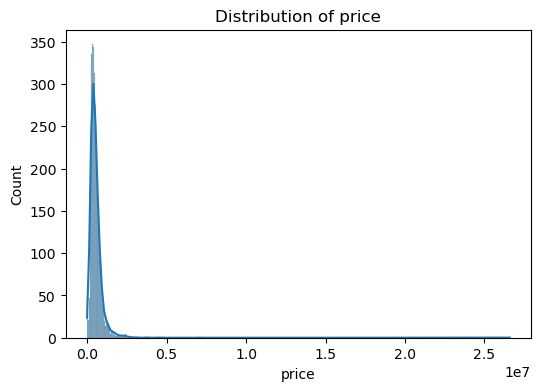

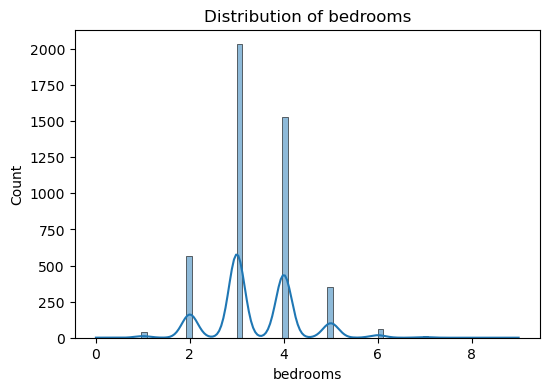

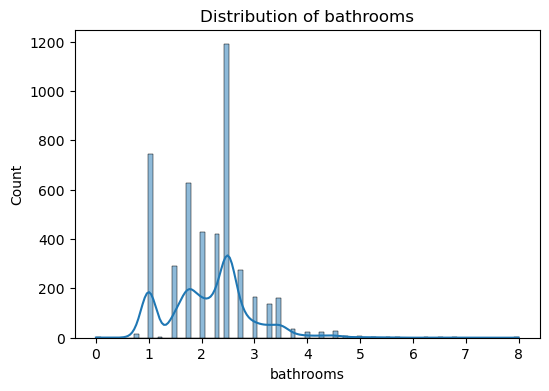

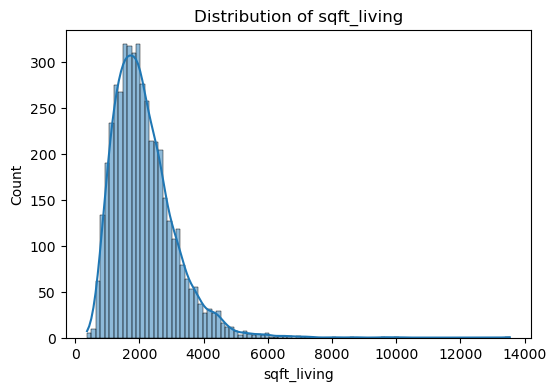

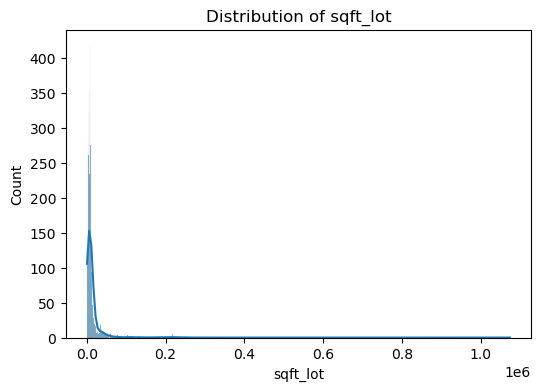

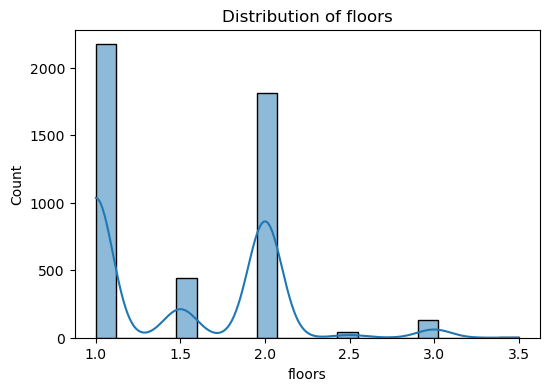

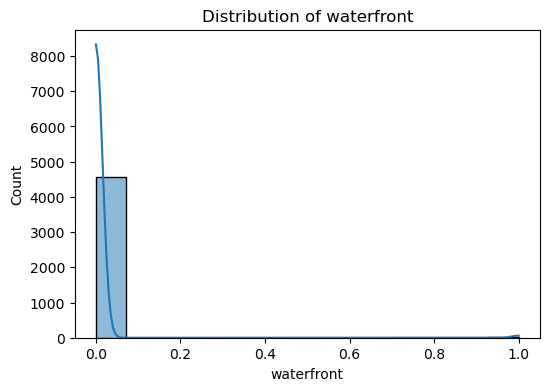

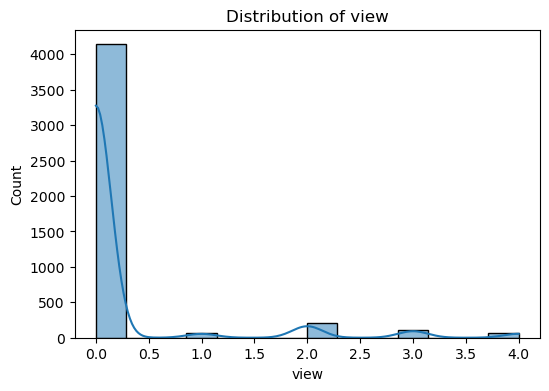

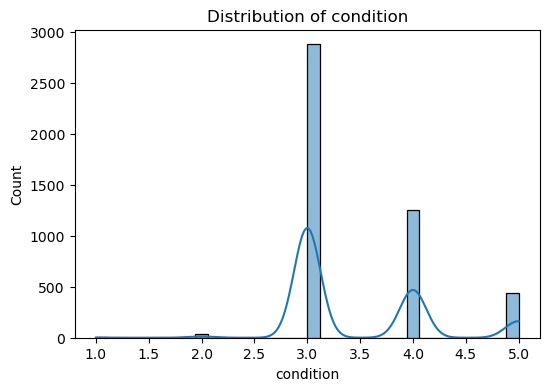

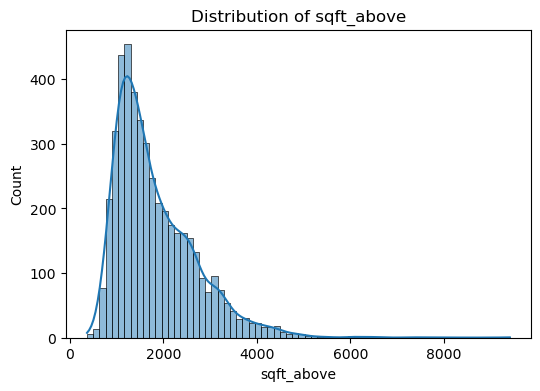

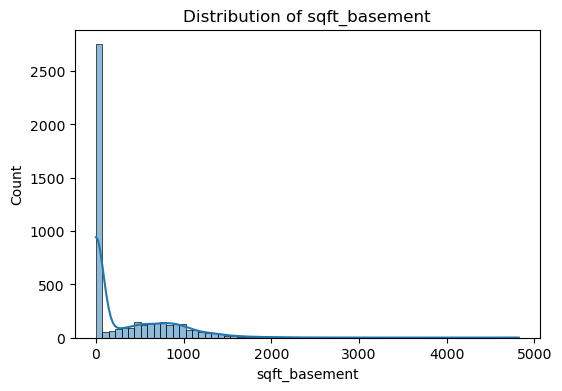

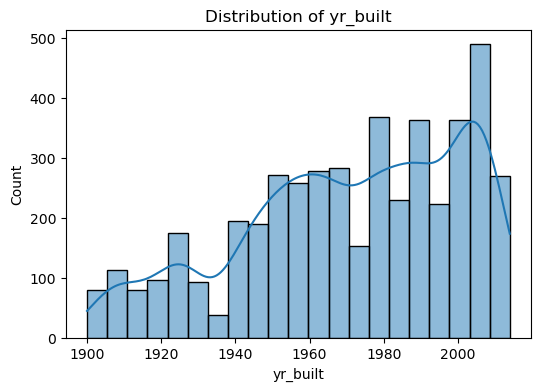

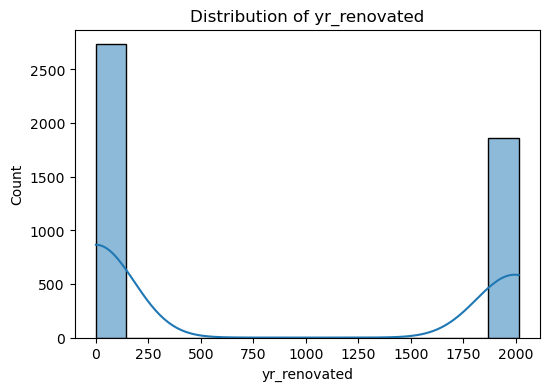

In [80]:
for each_col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(x = each_col, data = df, kde = True)
    plt.title(f'Distribution of {each_col}')
    plt.show()

###### (B) Box Plots 

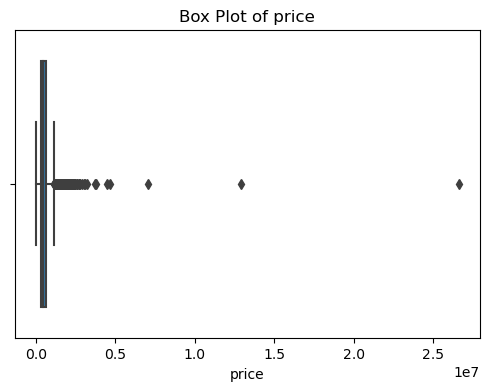

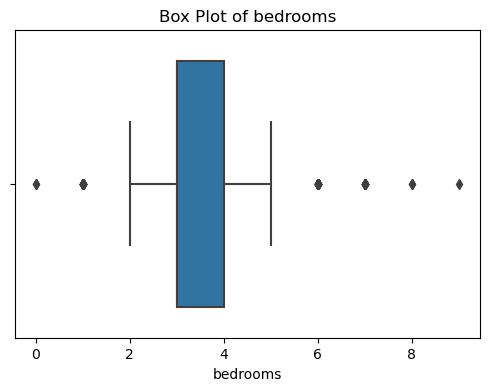

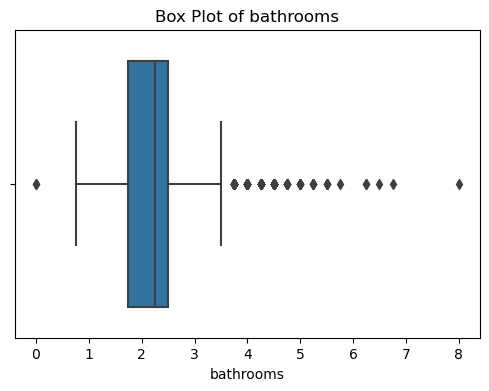

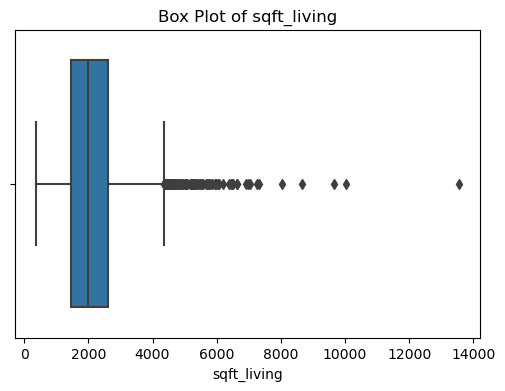

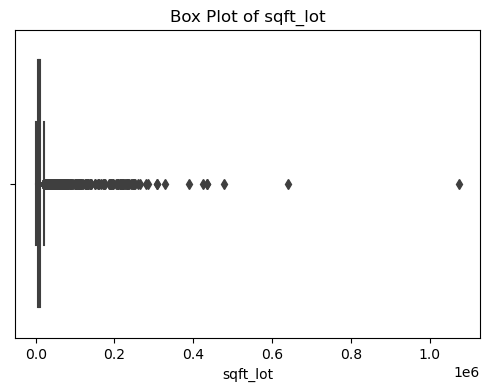

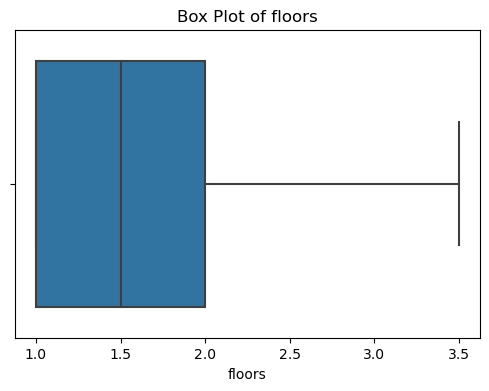

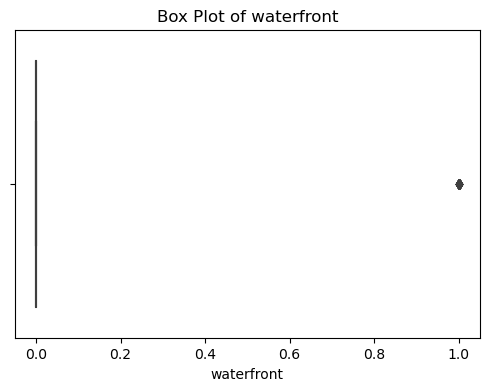

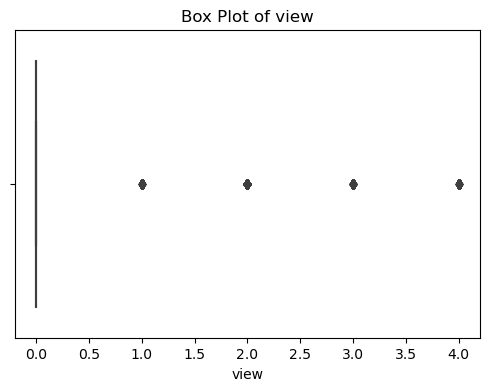

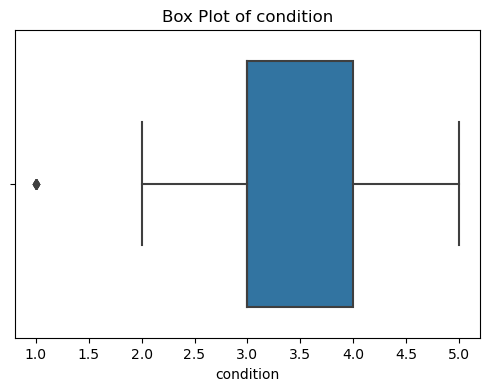

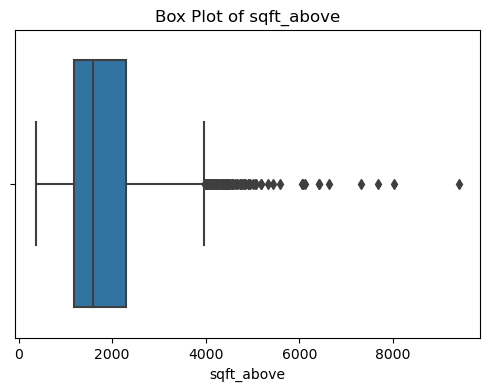

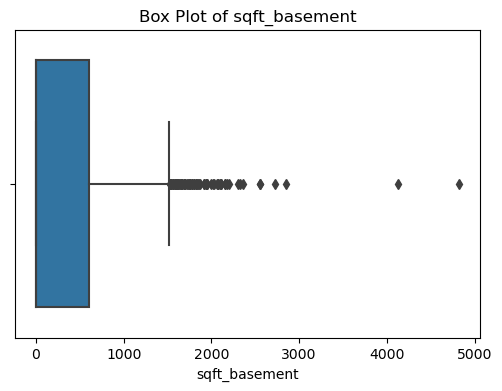

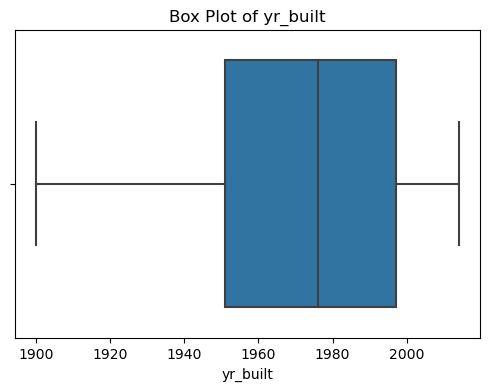

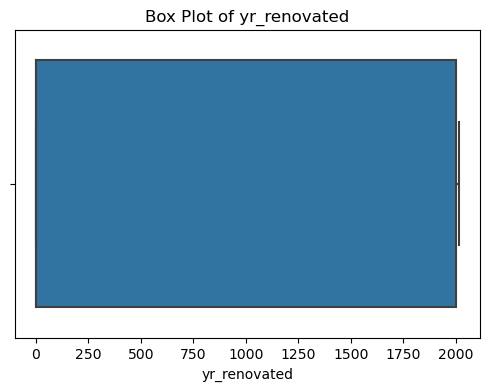

In [81]:
for each_col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x = each_col, data = df)
    plt.title(f'Box Plot of {each_col}')
    plt.show()

##### Visualizing Categorical Variables

###### (A) Count plots

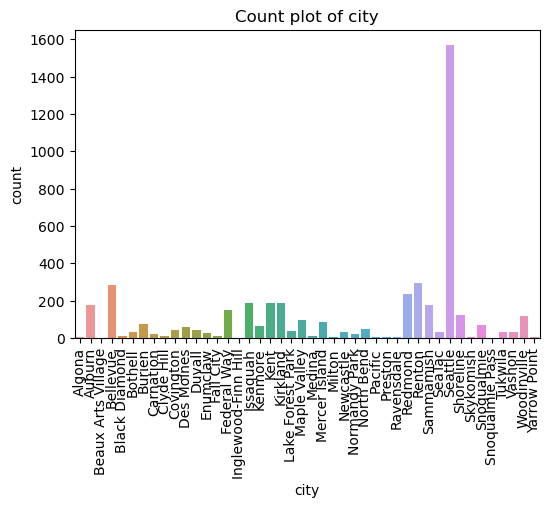

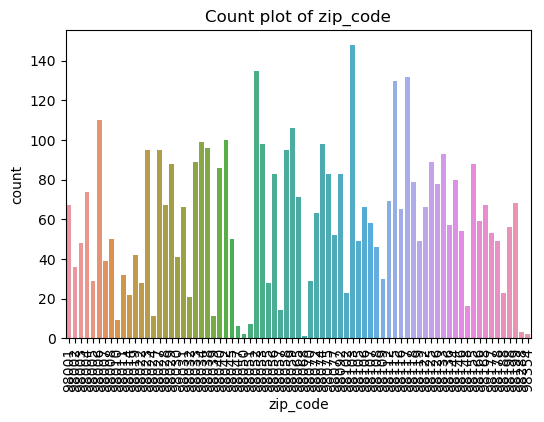

In [82]:
for each_col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x = each_col, data = df)
    plt.title(f'Count plot of {each_col}')
    plt.xticks(rotation = 90)
    plt.show()

##### Target variable Analysis

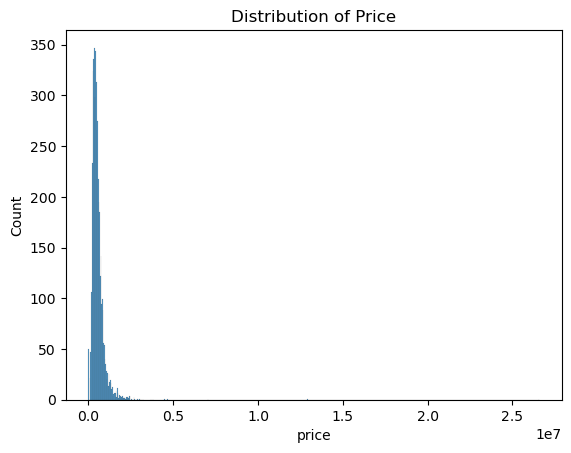

In [83]:
sns.histplot(df['price'])
plt.title('Distribution of Price')
plt.show()

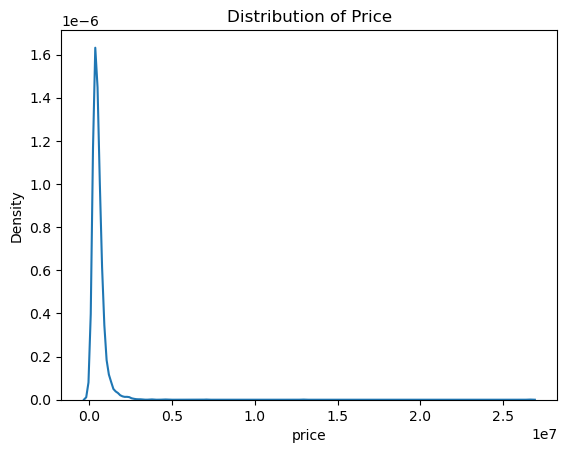

In [84]:
sns.kdeplot(df['price'])
plt.title('Distribution of Price')
plt.show()

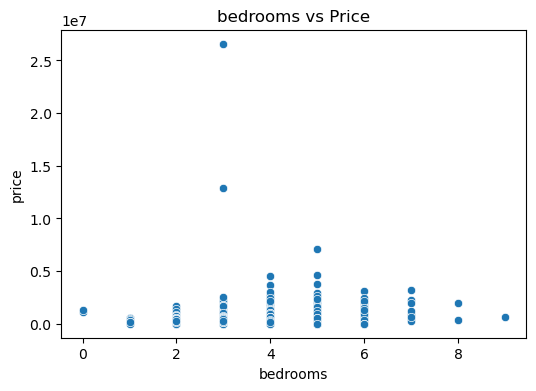

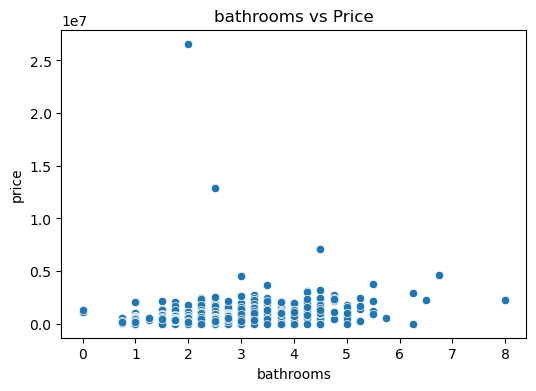

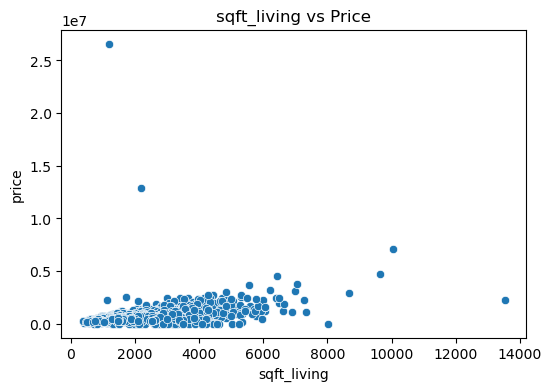

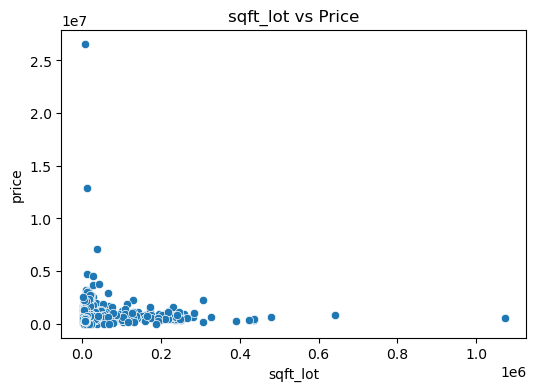

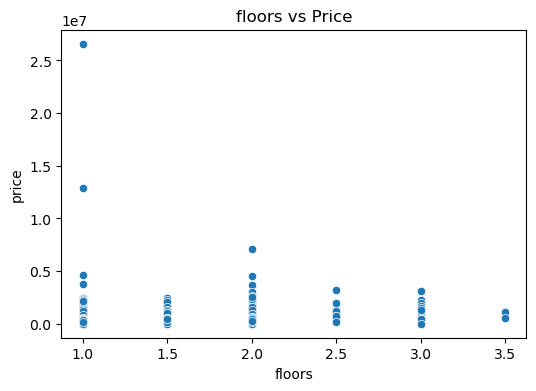

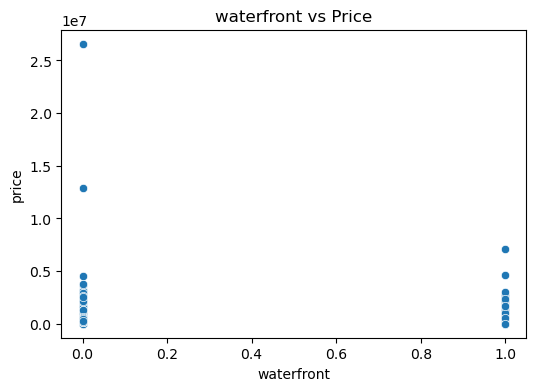

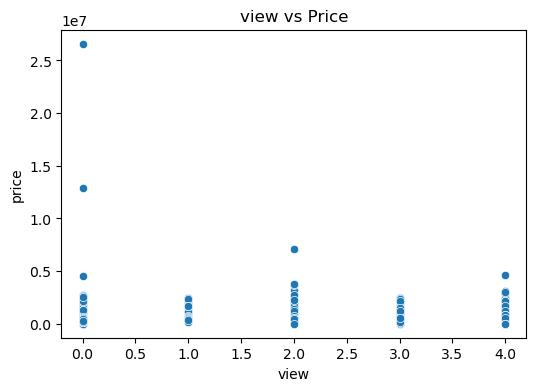

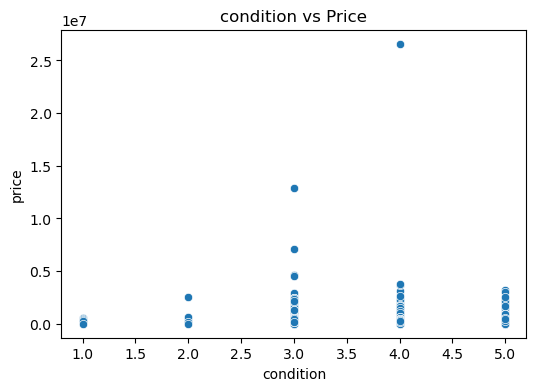

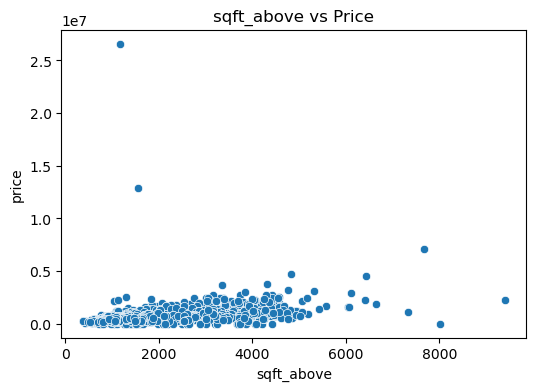

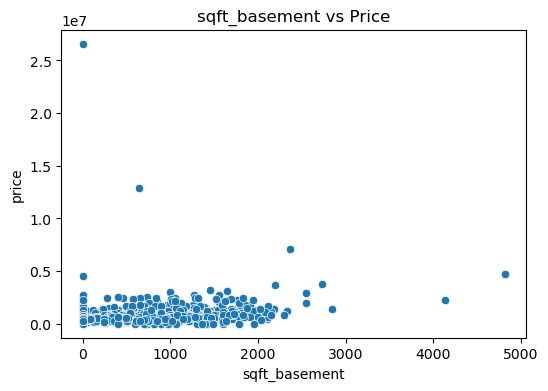

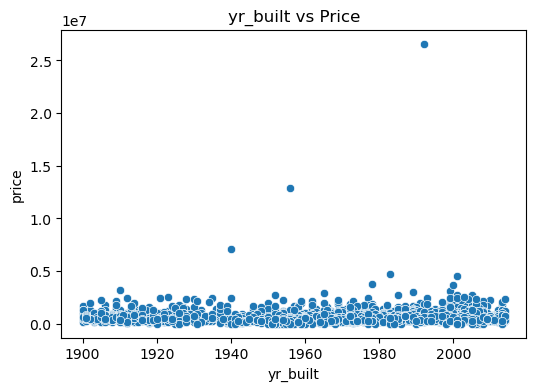

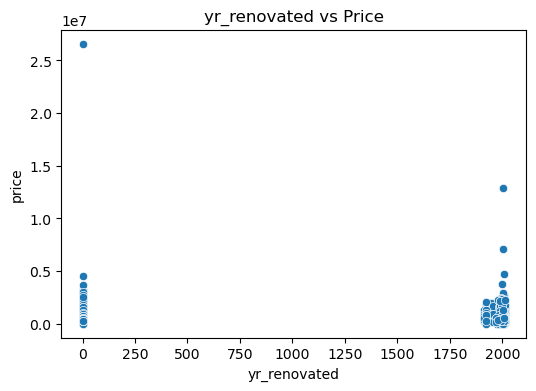

In [85]:
# Numerical V/s target 
for col in num_cols:
    if col != 'price':
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[col], y=df['price'])
        plt.title(f'{col} vs Price')
        plt.show()

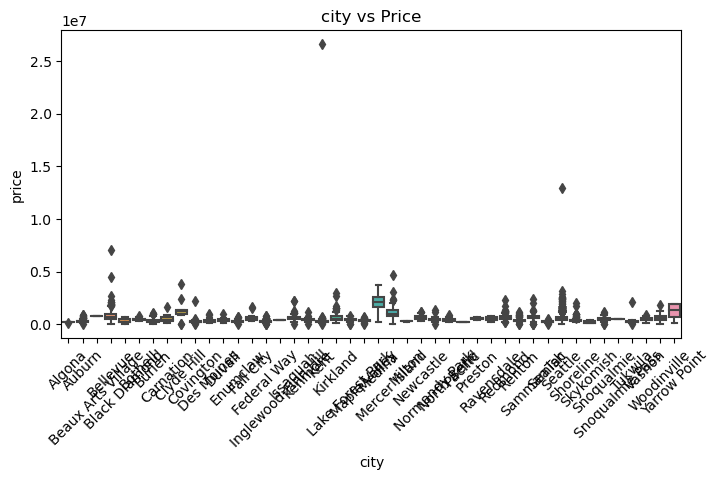

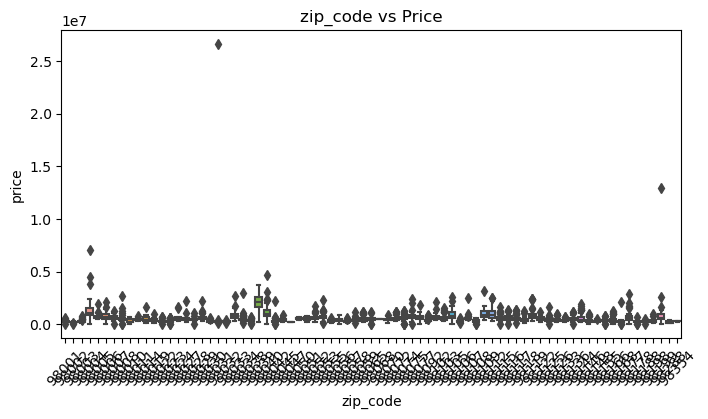

In [86]:
# Categorical V/S Target
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], y=df['price'])
    plt.title(f'{col} vs Price')
    plt.xticks(rotation=45)
    plt.show()

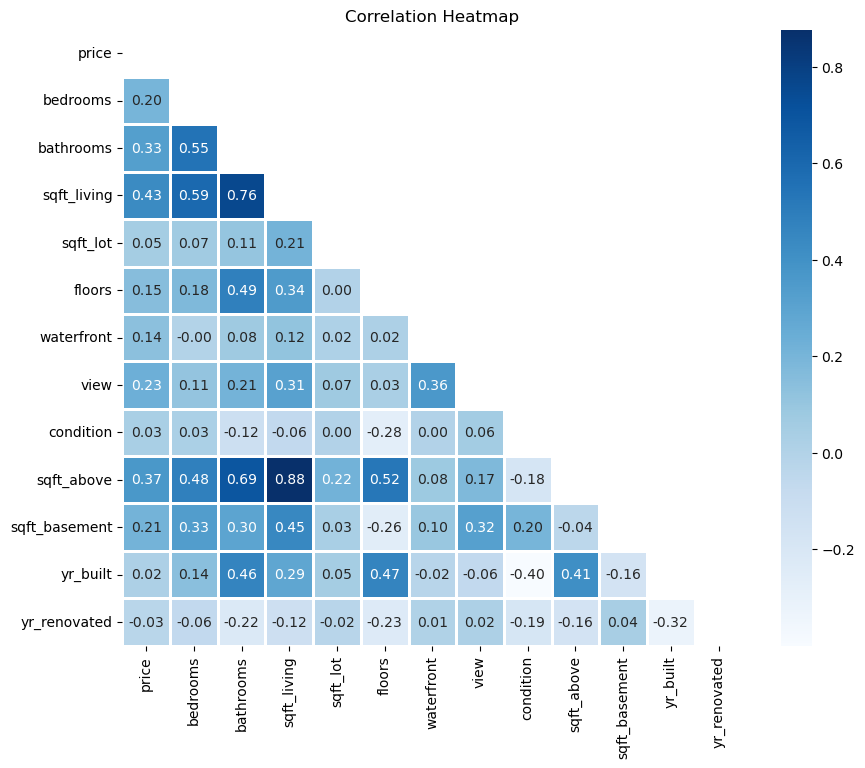

In [87]:
# Heatmap for finding out the multicoliieanerity 
plt.figure(figsize=(10,8))
corr = df.corr()

sns.heatmap(corr, 
    annot = True,           # Annotates each cell with the correlation coefficient
    fmt = '.2f',            # Formats the annotations to 2 decimal places
    linewidths = 0.725,     # Adds a line between cells
    linecolor = 'white',    # Color of the lines between cells
    mask = np.triu(corr),   # Masks the upper triangle of the heatmap to avoid redundancy
    cmap = 'Blues')


plt.title('Correlation Heatmap')
plt.show()

In [88]:
df_main = df.copy()

In [89]:
df_main.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,zip_code
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,98133
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,98119
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,98042
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,98008
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,98052


### Now doing the required Transformation And removing of the columns as needed from the plots above 

#### Basement Feature

In [90]:
df['has_basement'] = (df['sqft_basement'] > 0).astype(int)

#### Conversion of year built to house age as it makes the most sense rather than the house year built

In [91]:
df['house_age'] = 2026 - df['yr_built']

#### Renovation Feature

In [92]:
df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)

In [93]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,zip_code,has_basement,house_age,is_renovated
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,98133,0,71,1
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,98119,1,105,0
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,98042,0,60,0
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,98008,1,63,0
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,98052,1,50,1


### Handling the Outlier

#### Bedroom Cleaning

In [94]:
df = df[(df['bedrooms'] > 0) & (df['bedrooms'] < 7)]

#### Pricing outlier Capping and then applying the log transfrom on it to remove the outliers and the skweness of the data too


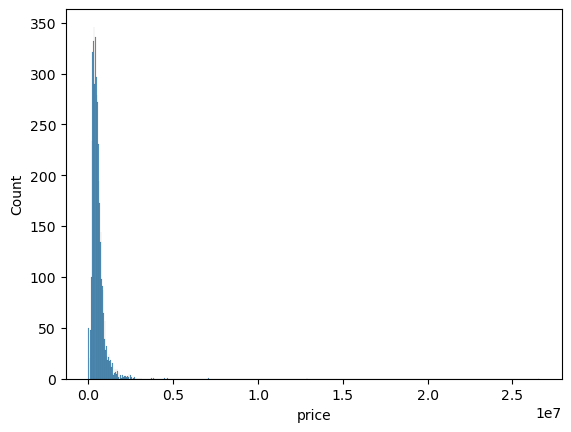

In [95]:
sns.histplot(x = 'price', data = df)
plt.show()

In [96]:
df = df[df['price'] < df['price'].quantile(0.99)]   # Quantiling

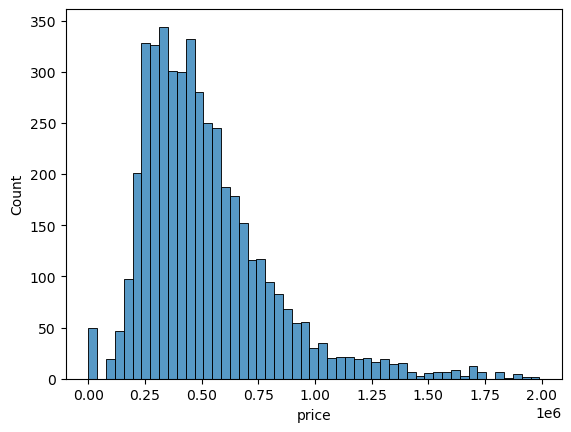

In [97]:
sns.histplot(x = 'price', data = df)
plt.show()

In [98]:
# df['price'] = np.log1p(df['price']) # Log transformation of the data 

#### 📊 What your histogram is telling you

From your plot:

Distribution is now much more symmetric ✅
Most values are centered around 12–13 (log scale)
Very few extreme values
Slight spike near 0 → likely original prices that were 0 or very small ⚠️

👉 Overall: Your target is now well-behaved

🧠 What this means

You have successfully:

✅ Reduced skewness
✅ Controlled outliers
✅ Made target closer to normal distribution

👉 This is ideal for regression models, especially:

Linear Regression

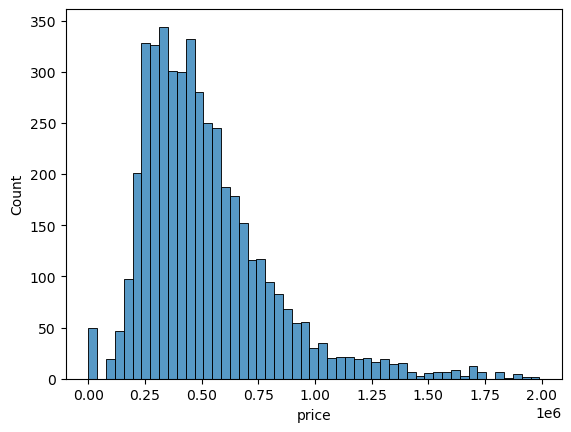

In [99]:
sns.histplot(x = 'price', data = df)
plt.show()

In [100]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,zip_code,has_basement,house_age,is_renovated
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,98133,0,71,1
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,98042,0,60,0
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,98008,1,63,0
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,98052,1,50,1
5,2014-05-02,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,Seattle,98115,0,88,1


#### Log transform on sqft_basement, sqft_living, sqft_lot

In [101]:
# df['sqft_basement'] = np.log1p(df['sqft_basement'])
# df['sqft_living'] = np.log1p(df['sqft_living'])
# df['sqft_lot'] = np.log1p(df['sqft_lot'])

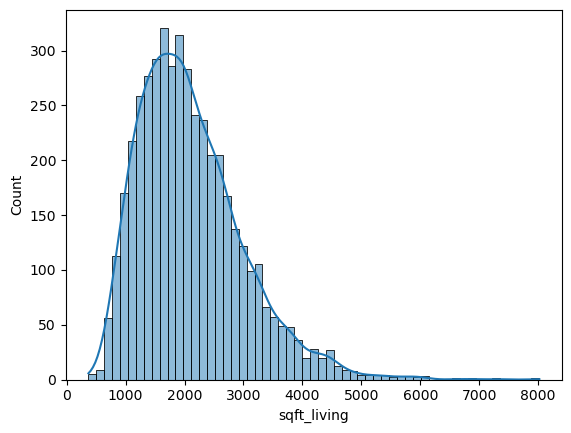

In [102]:
sns.histplot(x = 'sqft_living', data = df, kde = True)
plt.show()

#### Converting all the required colums into particular category column


In [103]:
df['floors'] = df['floors'].astype('category')


In [104]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,zip_code,has_basement,house_age,is_renovated
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,98133,0,71,1
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,98042,0,60,0
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,98008,1,63,0
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,98052,1,50,1
5,2014-05-02,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,Seattle,98115,0,88,1


In [105]:
df.dtypes

date             datetime64[ns]
price                   float64
bedrooms                float64
bathrooms               float64
sqft_living               int64
sqft_lot                  int64
floors                 category
waterfront                int64
view                      int64
condition                 int64
sqft_above                int64
sqft_basement             int64
yr_built                  int64
yr_renovated              int64
city                   category
zip_code               category
has_basement              int32
house_age                 int64
is_renovated              int32
dtype: object

#### Dropping all the unnesscary column

In [106]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'city', 'zip_code',
       'has_basement', 'house_age', 'is_renovated'],
      dtype='object')

In [107]:
df.drop(columns= ['sqft_above', 'yr_built', 'yr_renovated'], inplace = True)

In [108]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_basement,city,zip_code,has_basement,house_age,is_renovated
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,0,Shoreline,98133,0,71,1
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,0,Kent,98042,0,60,0
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,Bellevue,98008,1,63,0
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,800,Redmond,98052,1,50,1
5,2014-05-02,490000.0,2.0,1.00,880,6380,1.0,0,0,3,0,Seattle,98115,0,88,1


### Final Feature Selection

In [109]:
features = [
    'sqft_living',
    'bathrooms',
    'bedrooms',
    'floors',
    'waterfront',
    'view',
    'condition',
    'sqft_basement',
    'has_basement',
    'house_age',
    'is_renovated',
    'zip_code',
    'city'
]

X = df[features]
y = df['price']

In [110]:
X.head()

,sqft_living,bathrooms,bedrooms,floors,waterfront,view,condition,sqft_basement,has_basement,house_age,is_renovated,zip_code,city
0,1340,1.50,3.0,1.5,0,0,3,0,0,71,1,98133,Shoreline
2,1930,2.00,3.0,1.0,0,0,4,0,0,60,0,98042,Kent
3,2000,2.25,3.0,1.0,0,0,4,1000,1,63,0,98008,Bellevue
4,1940,2.50,4.0,1.0,0,0,4,800,1,50,1,98052,Redmond
5,880,1.00,2.0,1.0,0,0,3,0,0,88,1,98115,Seattle


In [111]:
X_linear_model = pd.get_dummies(X, columns=['zip_code', 'floors', 'city'], drop_first=True)
X_random_forest_model = pd.get_dummies(X, columns=['zip_code', 'floors', 'city'], drop_first=True)

## Linear Regression

### Train test split for linear Model

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X_linear_model, y, test_size=0.2, random_state= 100)

### Scaling as it is a linear model (Works on distance method)

In [113]:
scaler = StandardScaler()   # Making the object of the StandardScaler Class

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Building (Linear Regression)

In [114]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred = linear_model.predict(X_test_scaled)

In [115]:
y_pred = linear_model.predict(X_test)

# # Converting back to original Scale
# y_test_exp = np.expm1(y_test)
# y_pred_exp = np.expm1(y_pred)

c:\Users\Jeffrey\anaconda3\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


### Metrics of Linear Regression

In [117]:
print(f'R2 Score : {r2_score(y_test, y_pred)}')


R2 Score : -1.6794139899912147e+23


## Random Forest

### Train test split


In [118]:
X_train, X_test, y_train, y_test = train_test_split(X_random_forest_model, y, test_size=0.2, random_state= 100)

### Model Building (Random Forest)

In [119]:
rf = RandomForestRegressor(
    n_estimators=300,
    
)

rf.fit(X_train, y_train)



RandomForestRegressor(n_estimators=300)

In [120]:
y_pred = rf.predict(X_test)

# # Converting back to original Scale
# y_test_exp = np.expm1(y_test)
# y_pred_exp = np.expm1(y_pred)


### Metrics of Random Forest

In [121]:
print(f'R2 Score : {r2_score(y_test, y_pred)}')


R2 Score : 0.669377889097279


### Seeing the feature Importances

In [122]:
importances = rf.feature_importances_

feature_names = X_train.columns

for name, val in zip(feature_names, importances):
    print(name, val)

sqft_living 0.47035735392234235
bathrooms 0.032451150280122874
bedrooms 0.017633664477196657
waterfront 0.006154166178652558
view 0.02797052711638816
condition 0.011908163889535781
sqft_basement 0.02906402137460197
has_basement 0.0034019679593253072
house_age 0.07573882937277263
is_renovated 0.005428216159906227
zip_code_98002 7.291836632181248e-05
zip_code_98003 0.000253882153986281
zip_code_98004 0.028951161536606852
zip_code_98005 0.0011761399772863698
zip_code_98006 0.0020298163763316788
zip_code_98007 0.00027933614584690555
zip_code_98008 0.0022988297049314032
zip_code_98010 0.0002736612245541611
zip_code_98011 0.0002565931576982465
zip_code_98014 0.0005878134389202261
zip_code_98019 0.00020301013719504354
zip_code_98022 0.00010975070232392726
zip_code_98023 0.0010312172162289593
zip_code_98024 0.00019096458538539013
zip_code_98027 0.00035276349189406045
zip_code_98028 0.000654994704930738
zip_code_98029 0.0007376674628017199
zip_code_98030 0.00016802859556785507
zip_code_98031 5.

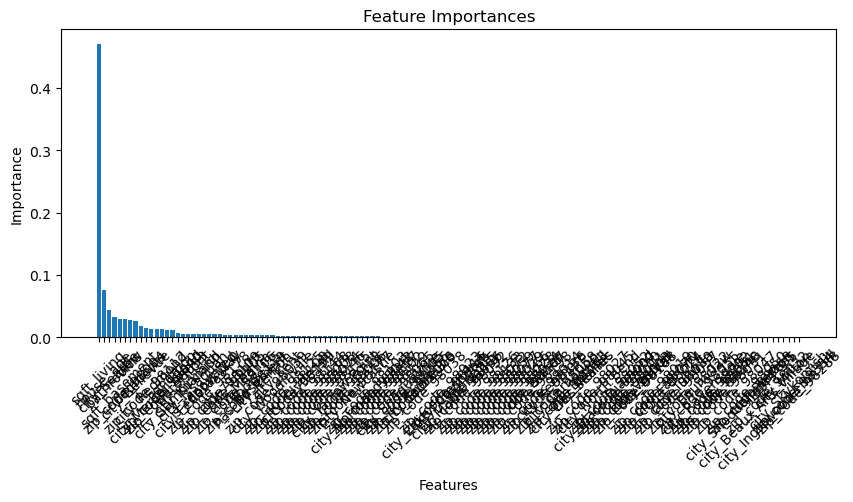

In [123]:
# Create a DataFrame for easy sorting and plotting
feat_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance
feat_importances = feat_importances.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,4))
plt.bar(feat_importances['Feature'], feat_importances['Importance'])
plt.xticks(rotation=45)
plt.title("Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

### From this able to figure out that one hot encoding is creating a lot of noise, so we have to fix that, adding of the column, total_sq_ft, trying the XGBoost

In [124]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_basement,city,zip_code,has_basement,house_age,is_renovated
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,0,Shoreline,98133,0,71,1
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,0,Kent,98042,0,60,0
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,Bellevue,98008,1,63,0
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,800,Redmond,98052,1,50,1
5,2014-05-02,490000.0,2.0,1.00,880,6380,1.0,0,0,3,0,Seattle,98115,0,88,1


#### ✅ FIX (VERY IMPORTANT)

Use Target Encoding: Zip Code and City too


In [125]:
df['zip_code_encoded'] = df.groupby('zip_code')['price'].transform('mean')
df['city_encoded'] = df.groupby('city')['price'].transform('mean')

df.drop(columns=['city', 'zip_code'], inplace=True)

In [126]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_basement,has_basement,house_age,is_renovated,zip_code_encoded,city_encoded
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,0,0,71,1,374807.507246,407960.832874
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,0,0,60,0,301257.544012,297370.120978
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1,63,0,560166.428571,779359.310205
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,800,1,50,1,637555.719367,658034.303320
5,2014-05-02,490000.0,2.0,1.00,880,6380,1.0,0,0,3,0,0,88,1,595086.468132,553449.992711


#### Removing the basement column and adding total sqft colum for incrasing the model prediction accuracy

In [127]:
# remove all the necessary columsn that you dont require,
df.drop(columns=['sqft_basement'], inplace= True)

In [128]:
df['total_sqft'] = df['sqft_living'] + df['sqft_lot']

In [129]:
df['price_per_sqft'] = df['price'] / df['total_sqft']

In [131]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,has_basement,house_age,is_renovated,zip_code_encoded,city_encoded,total_sqft,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,0,71,1,374807.507246,407960.832874,9252,33.830523
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,0,60,0,301257.544012,297370.120978,13877,24.645096
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1,63,0,560166.428571,779359.310205,10030,41.874377
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1,50,1,637555.719367,658034.303320,12440,44.212219
5,2014-05-02,490000.0,2.0,1.00,880,6380,1.0,0,0,3,0,88,1,595086.468132,553449.992711,7260,67.493113


### Random Forest with tuning and updated the dataset accordingly 

#### Making the features and target


In [132]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'has_basement',
       'house_age', 'is_renovated', 'zip_code_encoded', 'city_encoded',
       'total_sqft', 'price_per_sqft'],
      dtype='object')

In [133]:
features = [
        'bedrooms',
        'bathrooms',
        'sqft_living', 
        'sqft_lot',
        'floors', 
        'waterfront', 
        'view', 
        'condition', 
        'has_basement',
        'house_age', 
        'is_renovated', 
        'zip_code_encoded', 
        'city_encoded',
        'total_sqft',
        'price_per_sqft'
]

X = df[features]
y = df['price']

#### Train Test Split

In [134]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 45)

#### Model Building 

In [135]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, random_state=42)

#### Predicting and looking at the metrics 

In [136]:
y_pred = rf.predict(X_test)

In [137]:
print(f'R2 Score : {r2_score(y_test, y_pred)}')

R2 Score : 0.9086523416163044


In [ ]:
# # Converting back to original Scale
# y_test_exp = np.expm1(y_test)
# y_pred_exp = np.expm1(y_pred)

In [ ]:
# print(f'R2 Score : {r2_score(y_test_exp, y_pred_exp)}')

R2 Score : 0.9204285335293898


#### Feature Importances

In [138]:
importances = rf.feature_importances_

feature_names = X_train.columns

for name, val in zip(feature_names, importances):
    print(name, val)

bedrooms 0.0022438273223948845
bathrooms 0.006262586836436153
sqft_living 0.38591359975068845
sqft_lot 0.025112678167755018
floors 0.0017460266075493877
waterfront 0.0014959512909518912
view 0.011506004160634364
condition 0.0021247193251482115
has_basement 0.001460208819017471
house_age 0.009526936704555079
is_renovated 0.00131079247756366
zip_code_encoded 0.2878280359822129
city_encoded 0.01664369637581016
total_sqft 0.05744810008812547
price_per_sqft 0.18937683609115685


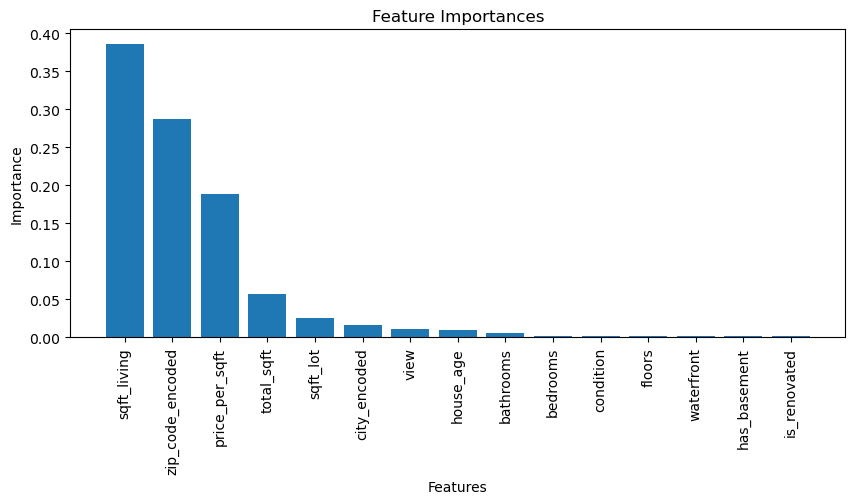

In [139]:
# Create a DataFrame for easy sorting and plotting
feat_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance
feat_importances = feat_importances.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,4))
plt.bar(feat_importances['Feature'], feat_importances['Importance'])
plt.xticks(rotation=90)
plt.title("Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

#### 👉 Look carefully:

price_per_sqft USES the target (price)
And you are trying to predict price
🧠 What This Means

You basically gave the model:

“Hey model, here is price hidden inside a feature… now predict price”

👉 So the model says:

“Easy 😎”

so that why we will be immedialtey removing that particular column

### Random forest after the following hypothesis

In [140]:
df.drop(columns=['price_per_sqft'], inplace= True)

#### Feature Selection

In [141]:
features = [
        'bedrooms',
        'bathrooms',
        'sqft_living', 
        'sqft_lot',
        'floors', 
        'waterfront', 
        'view', 
        'condition', 
        'has_basement',
        'house_age', 
        'is_renovated', 
        'zip_code_encoded', 
        'city_encoded',
        'total_sqft',
]

X = df[features]
y = df['price']

#### Train Test Split

In [142]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 45)

#### Model Building 

In [143]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, random_state=42)

#### Predicting and looking at the metrics

In [146]:
y_pred = rf.predict(X_test)

print(f'R2 Score : {r2_score(y_test, y_pred)}')

R2 Score : 0.7155271645347205


In [147]:
# # Converting back to original Scale
# y_test_exp = np.expm1(y_test)
# y_pred_exp = np.expm1(y_pred)

# print(f'R2 Score : {r2_score(y_test_exp, y_pred_exp)}')

#### Feature Importances 

In [148]:
importances = rf.feature_importances_

feature_names = X_train.columns

for name, val in zip(feature_names, importances):
    print(f'{name} --> {val}')

bedrooms --> 0.010056667362427486
bathrooms --> 0.024843809299007803
sqft_living --> 0.4371123022305346
sqft_lot --> 0.019969173559289077
floors --> 0.008491181440035724
waterfront --> 0.004860361540767004
view --> 0.03198054536504307
condition --> 0.008390117356639023
has_basement --> 0.004562244943169817
house_age --> 0.041083938644794205
is_renovated --> 0.00440417965646632
zip_code_encoded --> 0.3526948278100286
city_encoded --> 0.031004970571050987
total_sqft --> 0.020545680220746262


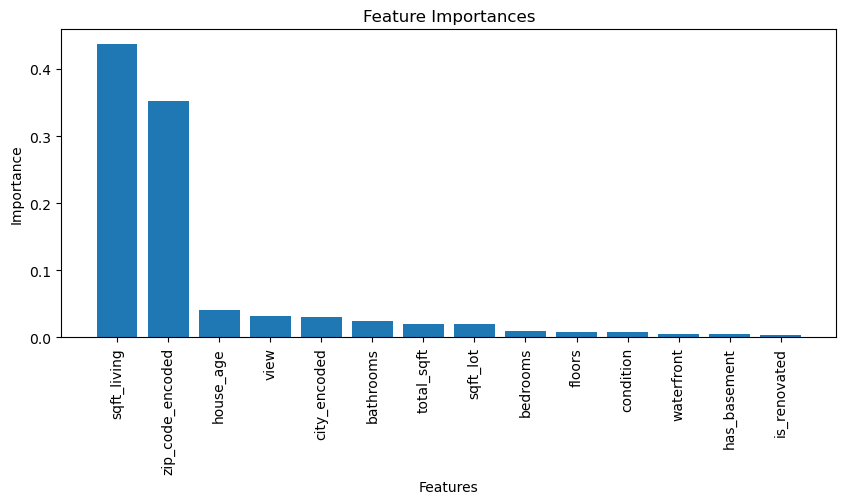

In [149]:
# Create a DataFrame for easy sorting and plotting
feat_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance
feat_importances = feat_importances.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,4))
plt.bar(feat_importances['Feature'], feat_importances['Importance'])
plt.xticks(rotation=90)
plt.title("Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

### XGBoost

In [150]:
features = [
        'bedrooms',
        'bathrooms',
        'sqft_living', 
        'sqft_lot',
        'floors', 
        'waterfront', 
        'view', 
        'condition', 
        'has_basement',
        'house_age', 
        'is_renovated', 
        'zip_code_encoded', 
        'city_encoded',
        'total_sqft',
]

X = df[features]
y = df['price']

In [151]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 45)

In [ ]:
# X_train = pd.get_dummies(X_train, drop_first=True)
# X_test = pd.get_dummies(X_test, drop_first=True)

# # Align columns (VERY IMPORTANT)
# X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [152]:
X_train['floors'] = X_train['floors'].astype(int)
X_test['floors'] = X_test['floors'].astype(int)

In [153]:
X_train.head()


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,has_basement,house_age,is_renovated,zip_code_encoded,city_encoded,total_sqft
4114,4.0,2.5,3180,31931,1,0,0,4,1,48,1,629632.456140,779359.310205,35111
2028,3.0,2.5,2550,13458,2,0,0,3,0,36,1,776720.275463,779359.310205,16008
4424,3.0,1.5,1430,8960,1,0,0,4,0,73,1,434484.543315,348947.248498,10390
1296,3.0,2.5,1620,1173,3,0,4,3,1,18,0,578713.247554,553449.992711,2793
759,4.0,2.0,2560,7798,1,0,0,4,1,79,1,595086.468132,553449.992711,10358


In [154]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)


In [155]:
print(f'R2 Score : {r2_score(y_test, y_pred)}')

R2 Score : 0.7244198497652938


In [161]:
# Converting back to original Scale
# y_test_exp = np.expm1(y_test)
# y_pred_exp = np.expm1(y_pred)

# print(f'R2 Score : {r2_score(y_test_exp, y_pred_exp)}')

In [158]:
# ## Apply Cross validation and commit it into the main branch 

# from sklearn.model_selection import cross_val_score

# scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
# print(scores.mean())

In [160]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(xgb, X.values, y.values, cv=5, scoring='r2')

print("CV Scores:", scores)
print("Mean CV R2:", scores.mean())

CV Scores: [0.78417541 0.79911393 0.78605862 0.77655304 0.26732116]
Mean CV R2: 0.6826444316693501
